# Traffic Pattern Analysis — Competition Pipeline

Leakage-aware Google Colab pipeline using:

- EDA and data checks
- Seasonal baseline
- LightGBM for stations with labeled history
- Cold-start LightGBM for unseen stations
- Static roadway and graph features
- Exact-time lag features
- 90% uncertainty intervals
- Reliability scores

In [1]:
# CELL 1 — Install packages
!pip -q install lightgbm pyarrow

In [2]:
# CELL 2 — Upload competition files
from google.colab import files
uploaded = files.upload()

# Upload at least:
# traffic_train.parquet
# traffic_validation.parquet
# network.csv
# network_edges.csv
# submission_template.csv
# scenario_template.csv
# validate_submission.py

Saving network.csv to network.csv
Saving network_edges.csv to network_edges.csv
Saving scenario_template.csv to scenario_template.csv
Saving submission_template.csv to submission_template.csv
Saving traffic_train.parquet to traffic_train.parquet
Saving traffic_validation.parquet to traffic_validation.parquet
Saving validate_submission.py to validate_submission.py


In [3]:
# CELL 3 — Imports and flexible file discovery
from pathlib import Path
import glob
import os
import sys
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

DATA_DIR = Path("/content")

def find_one(stem, suffix=None):
    matches = glob.glob(str(DATA_DIR / f"*{stem}*"))
    if suffix:
        matches = [m for m in matches if m.lower().endswith(suffix.lower())]
    if not matches:
        raise FileNotFoundError(f"Could not find a file containing: {stem}")
    matches = sorted(matches, key=lambda p: (len(Path(p).name), Path(p).name))
    return Path(matches[0])

TRAIN_PATH = find_one("traffic_train", ".parquet")
VALID_PATH = find_one("traffic_validation", ".parquet")
NETWORK_PATH = find_one("network", ".csv")

EDGE_MATCHES = [Path(p) for p in glob.glob(str(DATA_DIR / "*network_edges*.csv"))]
if not EDGE_MATCHES:
    raise FileNotFoundError("network_edges.csv not found")
EDGES_PATH = EDGE_MATCHES[0]

SUBMISSION_PATH = find_one("submission_template", ".csv")
SCENARIO_PATH = find_one("scenario_template", ".csv")
VALIDATOR_PATH = find_one("validate_submission", ".py")

print("Train:", TRAIN_PATH)
print("Validation:", VALID_PATH)
print("Network:", NETWORK_PATH)
print("Edges:", EDGES_PATH)
print("Submission:", SUBMISSION_PATH)

Train: /content/traffic_train.parquet
Validation: /content/traffic_validation.parquet
Network: /content/network.csv
Edges: /content/network_edges.csv
Submission: /content/submission_template.csv


In [4]:
# CELL 4 — Load data
train = pd.read_parquet(TRAIN_PATH)
validation = pd.read_parquet(VALID_PATH)
network = pd.read_csv(NETWORK_PATH)
edges = pd.read_csv(EDGES_PATH)
submission_template = pd.read_csv(SUBMISSION_PATH)
scenario_template = pd.read_csv(SCENARIO_PATH)

for df in [train, validation, submission_template]:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["station_key"] = df["station_key"].astype(str)
    df["direction_code"] = (
        df["direction_code"]
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

network["station_key"] = network["station_key"].astype(str)
edges["from_station_key"] = edges["from_station_key"].astype(str)
edges["to_station_key"] = edges["to_station_key"].astype(str)

print("train:", train.shape)
print("validation:", validation.shape)
print("network:", network.shape)
print("edges:", edges.shape)
print("forecast targets:", submission_template.shape)

print("\nTrain dates:", train["timestamp"].min(), "to", train["timestamp"].max())
print("Validation dates:", validation["timestamp"].min(), "to", validation["timestamp"].max())

print("\nTrain stations:", train["station_key"].nunique())
print("Validation stations:", validation["station_key"].nunique())
print("Network stations:", network["station_key"].nunique())
print("Target stations:", submission_template["station_key"].nunique())

required = {"station_key", "direction_code", "timestamp", "volume"}
assert required.issubset(train.columns)
assert required.issubset(validation.columns)

print("\nTraining columns:")
print(train.columns.tolist())

train: (902902, 9)
validation: (556800, 9)
network: (127, 8)
edges: (186, 4)
forecast targets: (170956, 8)

Train dates: 2024-01-01 00:00:00 to 2024-12-31 21:00:00
Validation dates: 2025-01-01 00:00:00 to 2025-06-30 23:00:00

Train stations: 75
Validation stations: 75
Network stations: 127
Target stations: 118

Training columns:
['station_key', 'timestamp', 'direction_code', 'direction', 'volume', 'hour', 'day_of_week', 'month', 'is_weekend']


Missing values in network:


,missing
station_key,0
through_lanes,0
speed_limit,0
functional_class,35
aadt_band,0
lane_width,0
roadway_width_band,0
surface_type,8



Volume summary:


,volume
count,902902.000000
mean,890.477242
std,1029.500596
min,0.000000
1%,1.000000
5%,10.000000
25%,206.000000
50%,574.000000
75%,1203.000000
95%,2778.000000


Exact validation/target overlap rows: 0
Target stations unseen in 2024 training: 43
Example unseen stations: ['STN_0001', 'STN_0002', 'STN_0016', 'STN_0019', 'STN_0020', 'STN_0024', 'STN_0028', 'STN_0029', 'STN_0030', 'STN_0032', 'STN_0033', 'STN_0038', 'STN_0041', 'STN_0042', 'STN_0043', 'STN_0044', 'STN_0045', 'STN_0046', 'STN_0054', 'STN_0055']


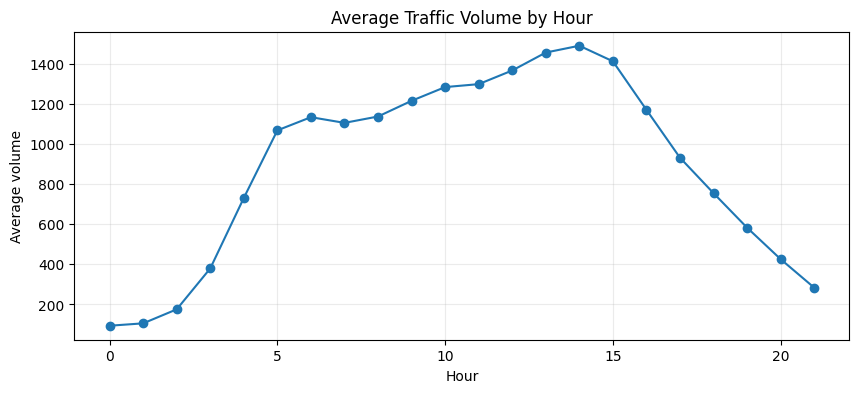

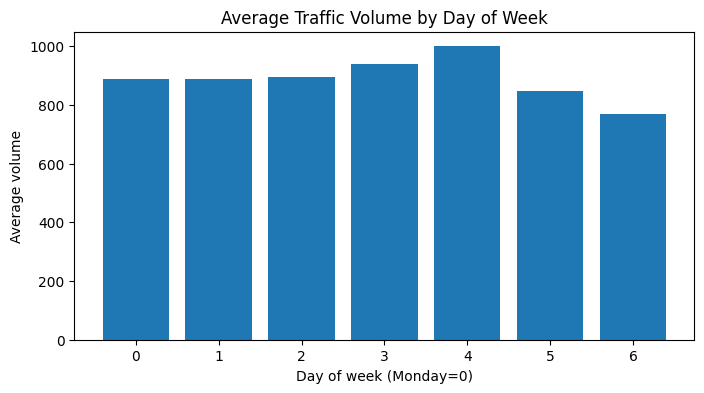

In [5]:
# CELL 5 — EDA and leakage checks
KEYS = ["station_key", "direction_code", "timestamp"]

print("Missing values in network:")
display(network.isna().sum().to_frame("missing"))

print("\nVolume summary:")
display(
    train["volume"]
    .describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])
    .to_frame()
)

target_keys = submission_template[KEYS].drop_duplicates()

validation_overlap = validation.merge(
    target_keys,
    on=KEYS,
    how="inner"
)

print("Exact validation/target overlap rows:", len(validation_overlap))

seen_train_stations = set(train["station_key"])
target_stations = set(submission_template["station_key"])
unseen_target_stations = sorted(target_stations - seen_train_stations)

print("Target stations unseen in 2024 training:", len(unseen_target_stations))
print("Example unseen stations:", unseen_target_stations[:20])

eda = train.copy()
eda["hour"] = eda["timestamp"].dt.hour
eda["day_of_week"] = eda["timestamp"].dt.dayofweek

hourly = eda.groupby("hour", as_index=False)["volume"].mean()
plt.figure(figsize=(10,4))
plt.plot(hourly["hour"], hourly["volume"], marker="o")
plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Average volume")
plt.grid(alpha=.25)
plt.show()

dow = eda.groupby("day_of_week", as_index=False)["volume"].mean()
plt.figure(figsize=(8,4))
plt.bar(dow["day_of_week"], dow["volume"])
plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day of week (Monday=0)")
plt.ylabel("Average volume")
plt.show()

In [6]:
# CELL 6 — Build static roadway + graph features
def build_graph_features(network, edges):
    a = edges.rename(
        columns={
            "from_station_key":"station_key",
            "to_station_key":"neighbor_key"
        }
    ).copy()

    b = edges.rename(
        columns={
            "to_station_key":"station_key",
            "from_station_key":"neighbor_key"
        }
    ).copy()

    e = pd.concat([a, b], ignore_index=True)

    e["is_same_corridor"] = (
        e["edge_type"].astype(str) == "same_corridor"
    ).astype(int)

    e["is_proximity"] = (
        e["edge_type"].astype(str) == "proximity"
    ).astype(int)

    e["dist_le_1"] = (
        e["distance_band"].astype(str) == "<=1mi"
    ).astype(int)

    e["dist_1_5"] = (
        e["distance_band"].astype(str) == "1-5mi"
    ).astype(int)

    e["dist_5_15"] = (
        e["distance_band"].astype(str) == "5-15mi"
    ).astype(int)

    topo = e.groupby("station_key").agg(
        graph_degree=("neighbor_key", "nunique"),
        same_corridor_degree=("is_same_corridor", "sum"),
        proximity_degree=("is_proximity", "sum"),
        neighbors_le_1mi=("dist_le_1", "sum"),
        neighbors_1_5mi=("dist_1_5", "sum"),
        neighbors_5_15mi=("dist_5_15", "sum"),
    ).reset_index()

    neighbor_static = network[
        ["station_key", "through_lanes", "speed_limit", "lane_width"]
    ].rename(
        columns={
            "station_key":"neighbor_key",
            "through_lanes":"neighbor_through_lanes",
            "speed_limit":"neighbor_speed_limit",
            "lane_width":"neighbor_lane_width"
        }
    )

    en = e.merge(neighbor_static, on="neighbor_key", how="left")

    nbr = en.groupby("station_key").agg(
        neighbor_mean_lanes=("neighbor_through_lanes", "mean"),
        neighbor_mean_speed=("neighbor_speed_limit", "mean"),
        neighbor_mean_lane_width=("neighbor_lane_width", "mean"),
    ).reset_index()

    graph = topo.merge(nbr, on="station_key", how="outer")
    out = network.merge(graph, on="station_key", how="left")

    graph_numeric = [
        "graph_degree","same_corridor_degree","proximity_degree",
        "neighbors_le_1mi","neighbors_1_5mi","neighbors_5_15mi",
        "neighbor_mean_lanes","neighbor_mean_speed","neighbor_mean_lane_width"
    ]

    for c in graph_numeric:
        out[c] = out[c].fillna(0)

    return out

station_context = build_graph_features(network, edges)
display(station_context.head())

,station_key,through_lanes,speed_limit,functional_class,aadt_band,lane_width,roadway_width_band,surface_type,graph_degree,same_corridor_degree,proximity_degree,neighbors_le_1mi,neighbors_1_5mi,neighbors_5_15mi,neighbor_mean_lanes,neighbor_mean_speed,neighbor_mean_lane_width
0,STN_0001,2.0,55.0,Other Principal Arterials,10k-25k,12.0,36-47,Composite,2,1,1,0,1,1,2.0,52.500000,11.500000
1,STN_0002,2.0,35.0,NaN,10k-25k,12.0,36-47,Asphalt,3,2,1,0,2,1,2.0,40.000000,12.000000
2,STN_0003,2.0,40.0,Minor Arterial,10k-25k,12.0,36-47,Composite,4,0,4,0,4,0,2.0,42.500000,13.250000
3,STN_0004,2.0,45.0,Other Principal Arterials,25k-50k,12.0,36-47,Composite,2,1,1,0,2,0,2.0,45.000000,12.000000
4,STN_0005,3.0,50.0,Other Principal Arterials,25k-50k,12.0,48-59,Composite,3,0,3,0,3,0,2.0,48.333333,11.666667


In [7]:
# CELL 7 — Feature engineering
LAGS = [24, 168, 336]

def add_time_features(df):
    out = df.copy()
    ts = pd.to_datetime(out["timestamp"])

    out["hour"] = ts.dt.hour.astype(np.int16)
    out["day_of_week"] = ts.dt.dayofweek.astype(np.int16)
    out["month"] = ts.dt.month.astype(np.int16)
    out["day_of_year"] = ts.dt.dayofyear.astype(np.int16)
    out["week_of_year"] = ts.dt.isocalendar().week.astype(np.int16)
    out["is_weekend"] = (ts.dt.dayofweek >= 5).astype(np.int8)

    out["hour_sin"] = np.sin(2*np.pi*out["hour"]/24)
    out["hour_cos"] = np.cos(2*np.pi*out["hour"]/24)
    out["dow_sin"] = np.sin(2*np.pi*out["day_of_week"]/7)
    out["dow_cos"] = np.cos(2*np.pi*out["day_of_week"]/7)
    out["doy_sin"] = np.sin(2*np.pi*out["day_of_year"]/365.25)
    out["doy_cos"] = np.cos(2*np.pi*out["day_of_year"]/365.25)

    return out

def add_exact_lags(rows, history, lags=LAGS):
    out = rows.copy()

    base = history[
        ["station_key","direction_code","timestamp","volume"]
    ].copy()

    base["timestamp"] = pd.to_datetime(base["timestamp"])

    base = (
        base.sort_values("timestamp")
        .drop_duplicates(
            ["station_key","direction_code","timestamp"],
            keep="last"
        )
    )

    for lag in lags:
        h = base.copy()
        h["timestamp"] = h["timestamp"] + pd.Timedelta(hours=lag)
        h = h.rename(columns={"volume":f"lag_{lag}"})

        out = out.merge(
            h[
                [
                    "station_key",
                    "direction_code",
                    "timestamp",
                    f"lag_{lag}"
                ]
            ],
            on=["station_key","direction_code","timestamp"],
            how="left"
        )

    return out

def add_context(df):
    out = df.merge(station_context, on="station_key", how="left")

    numeric_context = [
        "through_lanes","speed_limit","lane_width",
        "graph_degree","same_corridor_degree","proximity_degree",
        "neighbors_le_1mi","neighbors_1_5mi","neighbors_5_15mi",
        "neighbor_mean_lanes","neighbor_mean_speed","neighbor_mean_lane_width"
    ]

    for c in numeric_context:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
            med = pd.to_numeric(
                station_context[c],
                errors="coerce"
            ).median()
            if not np.isfinite(med):
                med = 0
            out[c] = out[c].fillna(med)

    cat_context = [
        "functional_class",
        "aadt_band",
        "roadway_width_band",
        "surface_type"
    ]

    for c in cat_context:
        if c in out.columns:
            out[c] = out[c].fillna("Unknown").astype(str)

    return out

def prepare_rows(rows, history_for_lags):
    out = rows.copy()
    out["station_key"] = out["station_key"].astype(str)
    out["direction_code"] = out["direction_code"].astype(str)
    out["timestamp"] = pd.to_datetime(out["timestamp"])

    out = add_time_features(out)
    out = add_context(out)
    out = add_exact_lags(out, history_for_lags)

    return out

TIME_FEATURES = [
    "hour","day_of_week","month","day_of_year",
    "week_of_year","is_weekend",
    "hour_sin","hour_cos","dow_sin","dow_cos",
    "doy_sin","doy_cos"
]

STATIC_NUM = [
    "through_lanes","speed_limit","lane_width",
    "graph_degree","same_corridor_degree","proximity_degree",
    "neighbors_le_1mi","neighbors_1_5mi","neighbors_5_15mi",
    "neighbor_mean_lanes","neighbor_mean_speed",
    "neighbor_mean_lane_width"
]

STATIC_CAT = [
    "direction_code",
    "functional_class",
    "aadt_band",
    "roadway_width_band",
    "surface_type"
]

LAG_FEATURES = [f"lag_{x}" for x in LAGS]

KNOWN_FEATURES = (
    ["station_key"]
    + STATIC_CAT
    + TIME_FEATURES
    + STATIC_NUM
    + LAG_FEATURES
)

COLD_FEATURES = STATIC_CAT + TIME_FEATURES + STATIC_NUM

KNOWN_CAT = ["station_key"] + STATIC_CAT
COLD_CAT = STATIC_CAT

In [8]:
# CELL 8 — Build safe history
validation_safe = validation.merge(
    target_keys.assign(_is_target=1),
    on=KEYS,
    how="left"
)

validation_safe = (
    validation_safe[
        validation_safe["_is_target"].isna()
    ]
    .drop(columns="_is_target")
)

print("Validation rows originally:", len(validation))
print("Validation rows safe for reuse:", len(validation_safe))
print(
    "Rows excluded because they match forecast targets:",
    len(validation) - len(validation_safe)
)

rolling_history = pd.concat(
    [train, validation_safe],
    ignore_index=True
)

late_training = pd.concat(
    [train, validation_safe],
    ignore_index=True
)

Validation rows originally: 556800
Validation rows safe for reuse: 556800
Rows excluded because they match forecast targets: 0


In [9]:
# CELL 9 — Prepare 2024 train and 2025 holdout
train_feat = prepare_rows(train, train)

# The model is trained only on 2024.
# Lag values for a 2025 row come only from exact earlier timestamps.
val_feat = prepare_rows(validation, rolling_history)

print("Train feature matrix:", train_feat.shape)
print("Validation feature matrix:", val_feat.shape)

Train feature matrix: (902902, 36)
Validation feature matrix: (556800, 36)


In [10]:
# CELL 10 — Categorical alignment + metrics
ALL_STATIONS = sorted(
    set(network["station_key"].astype(str))
    | set(train["station_key"].astype(str))
    | set(validation["station_key"].astype(str))
    | set(submission_template["station_key"].astype(str))
)

CATEGORY_VALUES = {
    "station_key": ALL_STATIONS
}

for c in STATIC_CAT:
    vals = []
    for df in [train_feat, val_feat]:
        if c in df.columns:
            vals.extend(
                df[c]
                .fillna("Unknown")
                .astype(str)
                .unique()
                .tolist()
            )

    CATEGORY_VALUES[c] = sorted(
        set(vals) | {"Unknown"}
    )

def cast_categories(df, cat_cols):
    out = df.copy()

    for c in cat_cols:
        cats = CATEGORY_VALUES[c]
        out[c] = pd.Categorical(
            out[c].fillna("Unknown").astype(str),
            categories=cats
        )

    return out

def score(y, pred, label="model"):
    pred = np.clip(np.asarray(pred), 0, None)

    mae = mean_absolute_error(y, pred)
    rmse = mean_squared_error(y, pred) ** 0.5

    print(
        f"{label:28s} "
        f"MAE={mae:,.3f} | RMSE={rmse:,.3f}"
    )

    return {
        "model":label,
        "MAE":mae,
        "RMSE":rmse
    }

In [11]:
# CELL 11 — Seasonal baseline
def build_baseline(train_df, pred_df):
    tr = add_time_features(train_df)
    pr = add_time_features(pred_df)

    g1 = tr.groupby(
        ["station_key","direction_code","day_of_week","hour"]
    )["volume"].median()

    g2 = tr.groupby(
        ["station_key","direction_code","hour"]
    )["volume"].median()

    g3 = tr.groupby(
        ["direction_code","day_of_week","hour"]
    )["volume"].median()

    global_med = tr["volume"].median()

    p = []

    for r in pr[
        ["station_key","direction_code","day_of_week","hour"]
    ].itertuples(index=False):

        v = g1.get(
            (
                r.station_key,
                r.direction_code,
                r.day_of_week,
                r.hour
            ),
            np.nan
        )

        if pd.isna(v):
            v = g2.get(
                (
                    r.station_key,
                    r.direction_code,
                    r.hour
                ),
                np.nan
            )

        if pd.isna(v):
            v = g3.get(
                (
                    r.direction_code,
                    r.day_of_week,
                    r.hour
                ),
                np.nan
            )

        if pd.isna(v):
            v = global_med

        p.append(v)

    return np.asarray(p)

baseline_pred = build_baseline(train, validation)

baseline_metrics = score(
    validation["volume"],
    baseline_pred,
    "Seasonal median baseline"
)

Seasonal median baseline     MAE=316.069 | RMSE=508.518


In [12]:
# CELL 12 — Main LightGBM: stations with history
train_known = cast_categories(
    train_feat[KNOWN_FEATURES],
    KNOWN_CAT
)

val_known = cast_categories(
    val_feat[KNOWN_FEATURES],
    KNOWN_CAT
)

known_model = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=1600,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.05,
    reg_lambda=0.50,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

known_model.fit(
    train_known,
    train_feat["volume"],
    categorical_feature=KNOWN_CAT,
    eval_set=[(val_known, val_feat["volume"])],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(
            120,
            verbose=False
        )
    ]
)

known_val_pred = np.clip(
    known_model.predict(val_known),
    0,
    None
)

known_metrics = score(
    validation["volume"],
    known_val_pred,
    "LightGBM known-station"
)

print("Best iteration:", known_model.best_iteration_)

LightGBM known-station       MAE=108.959 | RMSE=230.403
Best iteration: 990


In [13]:
# CELL 13 — Cold-start station model
rng = np.random.default_rng(42)

all_train_stations = np.array(
    sorted(train_feat["station_key"].unique())
)

n_hold = max(
    8,
    int(round(0.20 * len(all_train_stations)))
)

heldout_stations = set(
    rng.choice(
        all_train_stations,
        size=n_hold,
        replace=False
    )
)

cold_tr = train_feat[
    ~train_feat["station_key"].isin(heldout_stations)
].copy()

cold_te = train_feat[
    train_feat["station_key"].isin(heldout_stations)
].copy()

X_cold_tr = cast_categories(
    cold_tr[COLD_FEATURES],
    COLD_CAT
)

X_cold_te = cast_categories(
    cold_te[COLD_FEATURES],
    COLD_CAT
)

cold_sim_model = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=1200,
    learning_rate=0.035,
    num_leaves=63,
    min_child_samples=60,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.10,
    reg_lambda=0.75,
    random_state=43,
    n_jobs=-1,
    verbosity=-1
)

cold_sim_model.fit(
    X_cold_tr,
    cold_tr["volume"],
    categorical_feature=COLD_CAT,
    eval_set=[(X_cold_te, cold_te["volume"])],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(
            100,
            verbose=False
        )
    ]
)

cold_holdout_pred = np.clip(
    cold_sim_model.predict(X_cold_te),
    0,
    None
)

cold_metrics = score(
    cold_te["volume"],
    cold_holdout_pred,
    "Cold-start station holdout"
)

X_cold_all = cast_categories(
    train_feat[COLD_FEATURES],
    COLD_CAT
)

cold_model_early = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=max(
        300,
        int(cold_sim_model.best_iteration_ or 700)
    ),
    learning_rate=0.035,
    num_leaves=63,
    min_child_samples=60,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.10,
    reg_lambda=0.75,
    random_state=44,
    n_jobs=-1,
    verbosity=-1
)

cold_model_early.fit(
    X_cold_all,
    train_feat["volume"],
    categorical_feature=COLD_CAT
)

Cold-start station holdout   MAE=412.091 | RMSE=962.608


LGBMRegressor(colsample_bytree=0.9, learning_rate=0.035, min_child_samples=60,
              n_estimators=1192, n_jobs=-1, num_leaves=63,
              objective='regression_l1', random_state=44, reg_alpha=0.1,
              reg_lambda=0.75, subsample=0.9, verbosity=-1)

In [14]:
# CELL 14 — 90% uncertainty calibration
known_abs_err = np.abs(
    validation["volume"].to_numpy()
    - known_val_pred
)

cold_abs_err = np.abs(
    cold_te["volume"].to_numpy()
    - cold_holdout_pred
)

def finite_sample_quantile(errors, coverage=0.90):
    e = np.asarray(errors, dtype=float)
    e = e[np.isfinite(e)]
    e = np.sort(e)

    n = len(e)

    if n == 0:
        return np.nan

    k = int(
        np.ceil(
            (n + 1) * coverage
        )
    ) - 1

    k = min(
        max(k, 0),
        n - 1
    )

    return float(e[k])

KNOWN_Q90 = finite_sample_quantile(
    known_abs_err,
    0.90
)

COLD_Q90 = finite_sample_quantile(
    cold_abs_err,
    0.90
)

print(
    "Known-station 90% residual radius:",
    KNOWN_Q90
)

print(
    "Cold-start 90% residual radius:",
    COLD_Q90
)

known_lower = np.maximum(
    0,
    known_val_pred - KNOWN_Q90
)

known_upper = (
    known_val_pred + KNOWN_Q90
)

known_coverage = np.mean(
    (
        validation["volume"].to_numpy()
        >= known_lower
    )
    &
    (
        validation["volume"].to_numpy()
        <= known_upper
    )
)

print(
    "Known holdout empirical coverage:",
    known_coverage
)

Known-station 90% residual radius: 271.0797581961924
Cold-start 90% residual radius: 756.815853515231
Known holdout empirical coverage: 0.9000017959770115


In [15]:
# CELL 15 — Train final late-period models using reusable data through June 2025
late_feat = prepare_rows(
    late_training,
    late_training
)

late_trees = max(
    350,
    int(
        known_model.best_iteration_
        or 800
    )
)

X_late_known = cast_categories(
    late_feat[KNOWN_FEATURES],
    KNOWN_CAT
)

known_model_late = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=late_trees,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.05,
    reg_lambda=0.50,
    random_state=45,
    n_jobs=-1,
    verbosity=-1
)

known_model_late.fit(
    X_late_known,
    late_feat["volume"],
    categorical_feature=KNOWN_CAT
)

X_late_cold = cast_categories(
    late_feat[COLD_FEATURES],
    COLD_CAT
)

cold_model_late = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=max(
        350,
        int(
            cold_sim_model.best_iteration_
            or 700
        )
    ),
    learning_rate=0.035,
    num_leaves=63,
    min_child_samples=60,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.10,
    reg_lambda=0.75,
    random_state=46,
    n_jobs=-1,
    verbosity=-1
)

cold_model_late.fit(
    X_late_cold,
    late_feat["volume"],
    categorical_feature=COLD_CAT
)

LGBMRegressor(colsample_bytree=0.9, learning_rate=0.035, min_child_samples=60,
              n_estimators=1192, n_jobs=-1, num_leaves=63,
              objective='regression_l1', random_state=46, reg_alpha=0.1,
              reg_lambda=0.75, subsample=0.9, verbosity=-1)

In [16]:
# CELL 16 — Prepare final targets
targets = submission_template.copy()
targets["_row_order"] = np.arange(len(targets))

target_feat = prepare_rows(
    targets,
    rolling_history
)

EARLY_CUTOFF = pd.Timestamp(
    "2025-07-01"
)

target_feat["_period"] = np.where(
    target_feat["timestamp"] < EARLY_CUTOFF,
    "early",
    "late"
)

early_known_stations = set(
    train["station_key"]
)

late_known_stations = set(
    late_training["station_key"]
)

target_feat["_has_history"] = np.where(
    target_feat["_period"].eq("early"),
    target_feat["station_key"].isin(
        early_known_stations
    ),
    target_feat["station_key"].isin(
        late_known_stations
    )
)

print(
    target_feat[
        ["_period","_has_history"]
    ].value_counts()
)

_period  _has_history
late     True            120571
         False            26575
early    False            23810
Name: count, dtype: int64


In [17]:
# CELL 17 — Predict all target rows
pred = np.zeros(
    len(target_feat),
    dtype=float
)

interval_radius = np.zeros(
    len(target_feat),
    dtype=float
)

# Early + known
m = (
    (target_feat["_period"] == "early")
    &
    target_feat["_has_history"]
)

if m.any():
    X = cast_categories(
        target_feat.loc[
            m,
            KNOWN_FEATURES
        ],
        KNOWN_CAT
    )

    pred[m] = known_model.predict(X)
    interval_radius[m] = KNOWN_Q90

# Early + cold start
m = (
    (target_feat["_period"] == "early")
    &
    ~target_feat["_has_history"]
)

if m.any():
    X = cast_categories(
        target_feat.loc[
            m,
            COLD_FEATURES
        ],
        COLD_CAT
    )

    pred[m] = cold_model_early.predict(X)
    interval_radius[m] = COLD_Q90

# Late + known
m = (
    (target_feat["_period"] == "late")
    &
    target_feat["_has_history"]
)

if m.any():
    X = cast_categories(
        target_feat.loc[
            m,
            KNOWN_FEATURES
        ],
        KNOWN_CAT
    )

    pred[m] = known_model_late.predict(X)
    interval_radius[m] = KNOWN_Q90

# Late + cold start
m = (
    (target_feat["_period"] == "late")
    &
    ~target_feat["_has_history"]
)

if m.any():
    X = cast_categories(
        target_feat.loc[
            m,
            COLD_FEATURES
        ],
        COLD_CAT
    )

    pred[m] = cold_model_late.predict(X)
    interval_radius[m] = COLD_Q90

pred = np.clip(
    pred,
    0,
    None
)

has_history = (
    target_feat["_has_history"]
    .to_numpy()
)

rel = np.where(
    has_history,
    0.88,
    0.58
).astype(float)

lag_available = (
    target_feat[LAG_FEATURES]
    .notna()
    .sum(axis=1)
    .to_numpy()
)

rel += np.where(
    has_history,
    0.025 * lag_available,
    0
)

degree = (
    pd.to_numeric(
        target_feat["graph_degree"],
        errors="coerce"
    )
    .fillna(0)
    .to_numpy()
)

rel += np.where(
    ~has_history,
    np.minimum(degree, 5) * 0.025,
    0
)

relative_uncertainty = (
    interval_radius
    /
    np.maximum(pred, 100)
)

rel -= (
    np.clip(
        relative_uncertainty - 0.25,
        0,
        0.35
    )
    * 0.35
)

reliability = np.clip(
    rel,
    0.05,
    0.98
)

lower = np.maximum(
    0,
    pred - interval_radius
)

upper = (
    pred + interval_radius
)

lower = np.minimum(
    lower,
    pred
)

upper = np.maximum(
    upper,
    pred
)

print("Prediction summary")
print(pd.Series(pred).describe())

print("\nReliability summary")
print(pd.Series(reliability).describe())

Prediction summary
count    170956.000000
mean        703.338900
std         790.694016
min           0.000000
25%         207.183106
50%         444.593556
75%         844.304815
max        6921.591013
dtype: float64

Reliability summary
count    170956.000000
mean          0.725540
std           0.127899
min           0.507500
25%           0.557500
50%           0.757500
75%           0.814644
max           0.955000
dtype: float64


In [18]:
# CELL 18 — Build final forecast file
submission = submission_template.copy()

submission["forecast_volume"] = pred
submission["lower_90"] = lower
submission["upper_90"] = upper
submission["reliability_score"] = reliability

for c in [
    "forecast_volume",
    "lower_90",
    "upper_90",
    "reliability_score"
]:
    assert np.isfinite(
        submission[c]
    ).all(), f"Non-finite values in {c}"

assert (
    submission["forecast_volume"] >= 0
).all()

assert (
    submission["lower_90"] >= 0
).all()

assert (
    submission["lower_90"]
    <= submission["forecast_volume"]
).all()

assert (
    submission["forecast_volume"]
    <= submission["upper_90"]
).all()

assert (
    submission["reliability_score"]
    .between(0,1)
).all()

OUT = (
    "/content/"
    "traffic_forecast_submission.csv"
)

submission.to_csv(
    OUT,
    index=False
)

print("Saved:", OUT)
display(submission.head())

Saved: /content/traffic_forecast_submission.csv


,target_id,station_key,direction_code,timestamp,forecast_volume,lower_90,upper_90,reliability_score
0,T000001,STN_0001,1,2025-01-01 00:00:00,72.927152,0.0,829.743006,0.5075
1,T000002,STN_0001,1,2025-01-01 01:00:00,86.506354,0.0,843.322207,0.5075
2,T000003,STN_0001,1,2025-01-01 02:00:00,96.110133,0.0,852.925987,0.5075
3,T000004,STN_0001,1,2025-01-01 03:00:00,214.275559,0.0,971.091413,0.5075
4,T000005,STN_0001,1,2025-01-01 04:00:00,362.463637,0.0,1119.279491,0.5075


In [19]:
# CELL 19 — Run supplied official validator
result = subprocess.run(
    [
        sys.executable,
        str(VALIDATOR_PATH),
        OUT,
        "--template",
        str(SUBMISSION_PATH)
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print(result.stderr)

assert (
    result.returncode == 0
), "Submission validator failed."


Forecast file validation
------------------------
Rows: 170,956
Template rows: 170,956
Unique target IDs: 170,956
PASS: True



,feature,importance
0,station_key,11589
30,lag_24,6716
31,lag_168,6067
9,day_of_year,6032
32,lag_336,5865
7,day_of_week,4306
6,hour,4304
17,doy_cos,4288
16,doy_sin,4268
13,hour_cos,1559


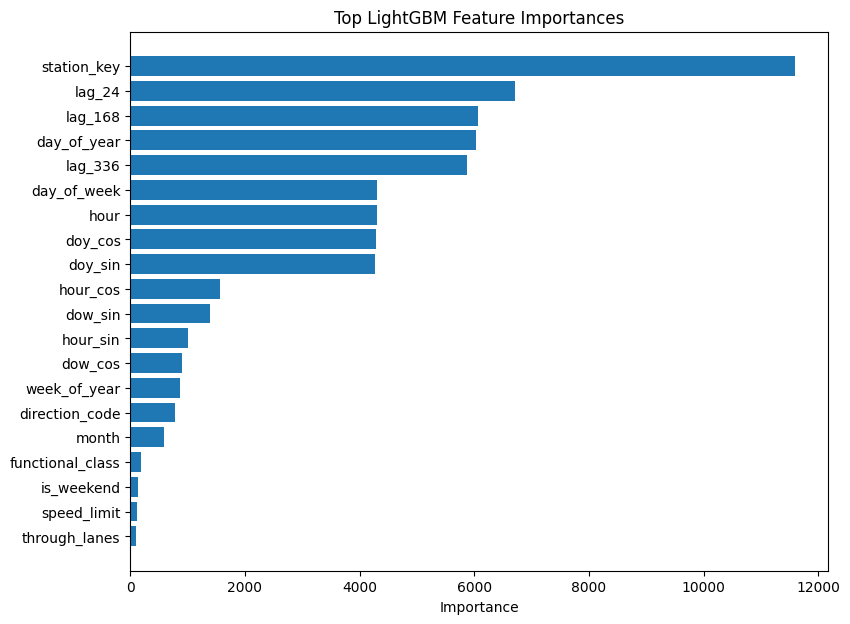

In [20]:
# CELL 20 — Feature importance
importance = pd.DataFrame({
    "feature": KNOWN_FEATURES,
    "importance": known_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(importance.head(25))

plt.figure(figsize=(9,7))
top = importance.head(20).sort_values("importance")
plt.barh(top["feature"], top["importance"])
plt.title("Top LightGBM Feature Importances")
plt.xlabel("Importance")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
# CELL 22 — Scenario template
display(scenario_template)

print("Scenario descriptions are not present in the supplied template.")
print("Do not invent the five scenario answers.")
print("Once the actual scenario prompts are supplied, fill:")
print("- estimated_volume_change_pct")
print("- lower_bound_pct")
print("- upper_bound_pct")
print("- recovery_time_hours")
print("- reliability_score")
print("- assumptions")

,scenario_id,station_key,estimated_volume_change_pct,lower_bound_pct,upper_bound_pct,recovery_time_hours,reliability_score,assumptions
0,SCENARIO_01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SCENARIO_02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SCENARIO_03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SCENARIO_04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SCENARIO_05,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Scenario descriptions are not present in the supplied template.
Do not invent the five scenario answers.
Once the actual scenario prompts are supplied, fill:
- estimated_volume_change_pct
- lower_bound_pct
- upper_bound_pct
- recovery_time_hours
- reliability_score
- assumptions


#Tried to Improve

In [23]:

# IMPROVED COLD-START: NEIGHBOR TRAFFIC PATTERN


def build_bidirectional_edge_map(edges):

    a = edges.rename(columns={
        "from_station_key": "station_key",
        "to_station_key": "neighbor_key"
    }).copy()

    b = edges.rename(columns={
        "to_station_key": "station_key",
        "from_station_key": "neighbor_key"
    }).copy()

    e = pd.concat([a, b], ignore_index=True)

    # Give more importance to same-corridor + nearby stations
    type_weight = {
        "same_corridor": 1.00,
        "proximity": 0.65
    }

    distance_weight = {
        "<=1mi": 1.00,
        "1-5mi": 0.70,
        "5-15mi": 0.40
    }

    e["edge_weight"] = (
        e["edge_type"].map(type_weight).fillna(0.5)
        *
        e["distance_band"].map(distance_weight).fillna(0.5)
    )

    return e[
        [
            "station_key",
            "neighbor_key",
            "edge_type",
            "distance_band",
            "edge_weight"
        ]
    ]


EDGE_MAP = build_bidirectional_edge_map(edges)


def neighbor_seasonal_forecast(rows, history):

    rows2 = add_time_features(rows.copy())
    history2 = add_time_features(history.copy())

    rows2["_rid"] = np.arange(len(rows2))

    # Neighbor profile with SAME direction


    profile_direction = (
        history2
        .groupby(
            [
                "station_key",
                "direction_code",
                "day_of_week",
                "hour"
            ],
            as_index=False
        )["volume"]
        .median()
        .rename(columns={
            "station_key": "neighbor_key",
            "volume": "neighbor_volume_direction"
        })
    )


    # Fallback profile ignoring direction


    profile_any_direction = (
        history2
        .groupby(
            [
                "station_key",
                "day_of_week",
                "hour"
            ],
            as_index=False
        )["volume"]
        .median()
        .rename(columns={
            "station_key": "neighbor_key",
            "volume": "neighbor_volume_any"
        })
    )


    # Connect target station to graph neighbors


    expanded = rows2[
        [
            "_rid",
            "station_key",
            "direction_code",
            "day_of_week",
            "hour"
        ]
    ].merge(
        EDGE_MAP,
        on="station_key",
        how="left"
    )

    # Same-direction traffic pattern
    expanded = expanded.merge(
        profile_direction,
        on=[
            "neighbor_key",
            "direction_code",
            "day_of_week",
            "hour"
        ],
        how="left"
    )

    # Direction-independent fallback
    expanded = expanded.merge(
        profile_any_direction,
        on=[
            "neighbor_key",
            "day_of_week",
            "hour"
        ],
        how="left"
    )

    expanded["neighbor_volume"] = (
        expanded["neighbor_volume_direction"]
        .fillna(expanded["neighbor_volume_any"])
    )

    valid = expanded["neighbor_volume"].notna()

    expanded["effective_weight"] = np.where(
        valid,
        expanded["edge_weight"],
        0
    )

    expanded["weighted_volume"] = (
        expanded["neighbor_volume"].fillna(0)
        *
        expanded["effective_weight"]
    )

    agg = (
        expanded
        .groupby("_rid")
        .agg(
            weighted_sum=("weighted_volume", "sum"),
            weight_sum=("effective_weight", "sum"),
            valid_neighbors=("neighbor_volume", "count")
        )
    )

    neighbor_prediction = np.full(
        len(rows2),
        np.nan
    )

    valid_rows = agg["weight_sum"] > 0

    idx = agg.index[valid_rows]

    neighbor_prediction[idx] = (
        agg.loc[valid_rows, "weighted_sum"]
        /
        agg.loc[valid_rows, "weight_sum"]
    )

    return neighbor_prediction

In [24]:

# REALISTIC COLD-START VALIDATION


rng = np.random.default_rng(123)

station_list = np.array(
    sorted(train["station_key"].unique())
)

n_holdout = max(
    10,
    int(len(station_list) * 0.20)
)

heldout_stations_v2 = set(
    rng.choice(
        station_list,
        size=n_holdout,
        replace=False
    )
)

print("Held-out stations:", len(heldout_stations_v2))



# Remove these stations COMPLETELY from training

cold_train_raw = train[
    ~train["station_key"].isin(
        heldout_stations_v2
    )
].copy()


# Test them in 2025
cold_test_raw = validation[
    validation["station_key"].isin(
        heldout_stations_v2
    )
].copy()


print("Cold training rows:", len(cold_train_raw))
print("Cold test rows:", len(cold_test_raw))


# Static LightGBM


cold_train_feat_v2 = prepare_rows(
    cold_train_raw,
    cold_train_raw
)

cold_test_feat_v2 = prepare_rows(
    cold_test_raw,
    cold_train_raw
)


X_train_v2 = cast_categories(
    cold_train_feat_v2[COLD_FEATURES],
    COLD_CAT
)

X_test_v2 = cast_categories(
    cold_test_feat_v2[COLD_FEATURES],
    COLD_CAT
)


cold_model_v2 = lgb.LGBMRegressor(

    objective="regression_l1",

    n_estimators=1500,

    learning_rate=0.03,

    num_leaves=63,

    min_child_samples=80,

    subsample=0.9,

    colsample_bytree=0.9,

    reg_alpha=0.1,

    reg_lambda=1.0,

    random_state=123,

    n_jobs=-1,

    verbosity=-1
)


cold_model_v2.fit(

    X_train_v2,

    cold_train_feat_v2["volume"],

    categorical_feature=COLD_CAT,

    eval_set=[
        (
            X_test_v2,
            cold_test_feat_v2["volume"]
        )
    ],

    eval_metric="rmse",

    callbacks=[
        lgb.early_stopping(
            120,
            verbose=False
        )
    ]
)


base_cold_pred = np.clip(
    cold_model_v2.predict(
        X_test_v2
    ),
    0,
    None
)


score(
    cold_test_raw["volume"],
    base_cold_pred,
    "Cold LightGBM V2"
)

Held-out stations: 15
Cold training rows: 722810
Cold test rows: 109776
Cold LightGBM V2             MAE=395.801 | RMSE=635.516


{'model': 'Cold LightGBM V2',
 'MAE': 395.80135956373834,
 'RMSE': 635.515577831428}

In [25]:

# NEIGHBOR FORECAST


neighbor_pred = neighbor_seasonal_forecast(
    cold_test_raw,
    cold_train_raw
)

valid_neighbor = np.isfinite(
    neighbor_pred
)

print(
    "Rows with usable graph neighbors:",
    valid_neighbor.sum(),
    "/",
    len(neighbor_pred)
)

if valid_neighbor.any():

    score(
        cold_test_raw.loc[
            valid_neighbor,
            "volume"
        ],
        neighbor_pred[
            valid_neighbor
        ],
        "Neighbor-only forecast"
    )

Rows with usable graph neighbors: 94380 / 109776
Neighbor-only forecast       MAE=442.690 | RMSE=637.158


In [26]:

# FIND BEST LIGHTGBM + NETWORK BLEND

y_true = cold_test_raw[
    "volume"
].to_numpy()

results = []


for alpha in np.arange(
    0,
    1.01,
    0.05
):

    # alpha = network weight
    blended = base_cold_pred.copy()

    blended[valid_neighbor] = (

        alpha
        * neighbor_pred[valid_neighbor]

        +

        (1 - alpha)
        * base_cold_pred[valid_neighbor]

    )

    mae = mean_absolute_error(
        y_true,
        blended
    )

    rmse = mean_squared_error(
        y_true,
        blended
    ) ** 0.5

    results.append(
        [
            alpha,
            mae,
            rmse
        ]
    )


blend_results = pd.DataFrame(
    results,
    columns=[
        "network_weight",
        "MAE",
        "RMSE"
    ]
)

display(
    blend_results.sort_values("MAE")
)


BEST_NETWORK_WEIGHT = (
    blend_results
    .sort_values("MAE")
    .iloc[0]["network_weight"]
)


print(
    "\\nBEST NETWORK WEIGHT:",
    BEST_NETWORK_WEIGHT
)

,network_weight,MAE,RMSE
3,0.15,393.947507,625.422488
2,0.10,394.014902,628.202024
4,0.20,394.352339,623.238763
1,0.05,394.605453,631.569502
5,0.25,395.161908,621.657125
0,0.00,395.801360,635.515578
6,0.30,396.372792,620.682180
7,0.35,397.950391,620.316785
8,0.40,399.890854,620.562020
9,0.45,402.165929,621.417160


\nBEST NETWORK WEIGHT: 0.15000000000000002


In [27]:

# FINAL IMPROVED COLD-START VALIDATION SCORE


improved_cold_pred = (
    base_cold_pred.copy()
)


improved_cold_pred[
    valid_neighbor
] = (

    BEST_NETWORK_WEIGHT
    * neighbor_pred[valid_neighbor]

    +

    (1 - BEST_NETWORK_WEIGHT)
    * base_cold_pred[valid_neighbor]

)


score(
    y_true,
    improved_cold_pred,
    "FINAL cold-start blend"
)


cold_blend_errors = np.abs(
    y_true
    -
    improved_cold_pred
)


COLD_Q90_IMPROVED = (
    finite_sample_quantile(
        cold_blend_errors,
        0.90
    )
)


print(
    "Improved cold-start 90% radius:",
    COLD_Q90_IMPROVED
)

FINAL cold-start blend       MAE=393.948 | RMSE=625.422
Improved cold-start 90% radius: 930.5372433793311


In [28]:

# CATBOOST COLD-START CHALLENGER


!pip -q install catboost

from catboost import CatBoostRegressor

# Prepare data


X_train_cat = cold_train_feat_v2[
    COLD_FEATURES
].copy()

X_test_cat = cold_test_feat_v2[
    COLD_FEATURES
].copy()


# CatBoost categorical columns must be strings
for col in COLD_CAT:

    X_train_cat[col] = (
        X_train_cat[col]
        .fillna("Unknown")
        .astype(str)
    )

    X_test_cat[col] = (
        X_test_cat[col]
        .fillna("Unknown")
        .astype(str)
    )


# Fix numeric columns
numeric_features = [
    c for c in COLD_FEATURES
    if c not in COLD_CAT
]

for col in numeric_features:

    X_train_cat[col] = pd.to_numeric(
        X_train_cat[col],
        errors="coerce"
    )

    X_test_cat[col] = pd.to_numeric(
        X_test_cat[col],
        errors="coerce"
    )

    median_value = X_train_cat[col].median()

    if pd.isna(median_value):
        median_value = 0

    X_train_cat[col] = (
        X_train_cat[col]
        .fillna(median_value)
    )

    X_test_cat[col] = (
        X_test_cat[col]
        .fillna(median_value)
    )


cat_indices = [
    X_train_cat.columns.get_loc(c)
    for c in COLD_CAT
]



# CatBoost


cat_model = CatBoostRegressor(

    loss_function="MAE",

    eval_metric="RMSE",

    iterations=1800,

    learning_rate=0.035,

    depth=9,

    l2_leaf_reg=6,

    random_seed=42,

    random_strength=0.5,

    verbose=100,

    allow_writing_files=False
)


cat_model.fit(

    X_train_cat,

    cold_train_feat_v2["volume"],

    cat_features=cat_indices,

    eval_set=(

        X_test_cat,

        cold_test_feat_v2["volume"]

    ),

    early_stopping_rounds=120,

    verbose=100
)


cat_pred = np.clip(

    cat_model.predict(
        X_test_cat
    ),

    0,

    None
)


score(

    cold_test_raw["volume"],

    cat_pred,

    "CatBoost cold-start"

)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00
0:	learn: 1071.9181529	test: 812.6108101	best: 812.6108101 (0)	total: 1.71s	remaining: 51m 17s
100:	learn: 294.9405125	test: 638.6516697	best: 635.8658045 (91)	total: 2m 26s	remaining: 40m 59s
200:	learn: 252.9825674	test: 639.2285434	best: 635.8658045 (91)	total: 4m 59s	remaining: 39m 45s
Stopped by overfitting detector  (120 iterations wait)

bestTest = 635.8658045
bestIteration = 91

Shrink model to first 92 iterations.
CatBoost cold-start          MAE=401.778 | RMSE=635.866


{'model': 'CatBoost cold-start',
 'MAE': 401.77777465268906,
 'RMSE': 635.8658044998709}

In [29]:

# LIGHTGBM + CATBOOST ENSEMBLE SEARCH


y_true = cold_test_raw[
    "volume"
].to_numpy()


ensemble_results = []


for cat_weight in np.arange(
    0,
    1.01,
    0.05
):

    combined = (

        cat_weight
        * cat_pred

        +

        (1 - cat_weight)
        * improved_cold_pred

    )


    mae = mean_absolute_error(
        y_true,
        combined
    )


    rmse = (
        mean_squared_error(
            y_true,
            combined
        ) ** 0.5
    )


    ensemble_results.append(

        [
            cat_weight,
            mae,
            rmse
        ]

    )


ensemble_results = pd.DataFrame(

    ensemble_results,

    columns=[

        "catboost_weight",

        "MAE",

        "RMSE"

    ]

)


display(

    ensemble_results
    .sort_values("MAE")

)


BEST_CAT_WEIGHT = (

    ensemble_results
    .sort_values("MAE")
    .iloc[0]["catboost_weight"]

)


print(

    "BEST CATBOOST WEIGHT:",

    BEST_CAT_WEIGHT

)

,catboost_weight,MAE,RMSE
1,0.05,393.898286,625.435886
2,0.10,393.901450,625.503293
0,0.00,393.947507,625.422488
3,0.15,393.951330,625.624690
4,0.20,394.046865,625.800048
5,0.25,394.187274,626.029319
6,0.30,394.371748,626.312445
7,0.35,394.603390,626.649354
8,0.40,394.880641,627.039957
9,0.45,395.201830,627.484156


BEST CATBOOST WEIGHT: 0.05


In [30]:
final_cold_candidate = (

    BEST_CAT_WEIGHT
    * cat_pred

    +

    (1 - BEST_CAT_WEIGHT)
    * improved_cold_pred

)


score(

    y_true,

    final_cold_candidate,

    "FINAL CatBoost + LightGBM"

)

FINAL CatBoost + LightGBM    MAE=393.898 | RMSE=625.436


{'model': 'FINAL CatBoost + LightGBM',
 'MAE': 393.8982857182245,
 'RMSE': 625.4358864070172}